In [2]:
import os
import datajoint as dj
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# change to the upper level folder to detect dj_local_conf.json
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
dj.config.load("/home/sgao/source/spyglass/notebooks/dj_local_conf.json")  # load config for database connection info

import spyglass.common as sgc
import spyglass.position.v1 as sgp
import spyglass.lfp.analysis.v1 as lfp_analysis
from spyglass.lfp import LFPOutput
import spyglass.lfp as sglfp
import spyglass.lfp as lfp
from spyglass.position import PositionOutput
from spyglass.lfp.v1.lfp_artifact import (
    LFPArtifactDetection,
    LFPArtifactDetectionParameters,
    LFPArtifactDetectionSelection,
)
import spyglass.ripple.v1 as sgrip
import spyglass.ripple.v1 as sgr

# ignore datajoint+jupyter async warnings
import warnings

warnings.simplefilter("ignore", category=DeprecationWarning)
warnings.simplefilter("ignore", category=ResourceWarning)

/home/sgao/source/miniforge3/envs/spyglass/lib/python3.10/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-09-12 11:57:29,144][INFO]: DataJoint is configured from /home/sgao/source/spyglass/notebooks/dj_local_conf.json
[2026-09-12 11:57:30,276][INFO]: DataJoint 0.14.5 connected to sgao@lmf-db.cin.ucsf.edu:3306


In [3]:
sgrip.RippleTimesV1() & {"nwb_file_name": 'Marcus20260801_.nwb'}

lfp_merge_id,filter_name descriptive name of this filter,filter_sampling_rate sampling rate for this filter,nwb_file_name name of the NWB file,target_interval_list_name descriptive name of this interval list,lfp_band_sampling_rate the sampling rate for this band,group_name,ripple_param_name a name for this set of parameters,pos_merge_id,analysis_file_name name of the file,ripple_times_object_id
008bb4aa-5cc4-3b06-3ecc-7b1185c057b7,Ripple 150-250 Hz,1000,Marcus20260801_.nwb,01_s1,1000,Ripple Detection Channels,default_trodes,f2e04a63-27bf-c5de-4d78-ed9eefa942df,Marcus20260801_QENAZUYNXH.nwb,14215ffb-0413-4997-83ca-986a7c01378e
12d3a444-fcb7-e9f0-be8d-a1a8129ff7d7,Ripple 150-250 Hz,1000,Marcus20260801_.nwb,05_s3,1000,Ripple Detection Channels,default_trodes,b22a600d-c286-d89f-e1e8-e6f22c87e3ff,Marcus20260801_QRSQNWW9UH.nwb,ddc5dd4d-6d95-485f-a871-8478d6d9ef17
4d9dba5b-81d8-a28d-04ad-2503ac95db58,Ripple 150-250 Hz,1000,Marcus20260801_.nwb,11_s6,1000,Ripple Detection Channels,default_trodes,7024f863-c0f7-abfc-b986-e95ceb19df0c,Marcus20260801_SZOA4Z22B9.nwb,f6891e9d-9e83-4b0e-a0ea-721676e4ab69
82600247-a4a6-d0e5-1930-4a343baf3649,Ripple 150-250 Hz,1000,Marcus20260801_.nwb,03_s2,1000,Ripple Detection Channels,default_trodes,57c27e50-ebc4-d3d2-36e0-89ef8bf5d1e0,Marcus20260801_GZUILVW6JW.nwb,bef4ec68-f299-449b-9f31-ce107a577417
c4d490cf-a82b-7ac9-99c9-78344fc1dce9,Ripple 150-250 Hz,1000,Marcus20260801_.nwb,09_s5,1000,Ripple Detection Channels,default_trodes,a9be6fdd-747e-6d4a-7ef3-bf7cf2dacc4d,Marcus20260801_0X85Q5CIXQ.nwb,9ec0a26f-d452-4ced-9ccb-6eb4b403cc80
e41b86eb-3cf0-9571-4605-97f1a9f37c2f,Ripple 150-250 Hz,1000,Marcus20260801_.nwb,07_s4,1000,Ripple Detection Channels,default_trodes,163e77fa-5f99-adcb-b33d-686ce4598de9,Marcus20260801_1KBT7W0VD8.nwb,6f5496e4-39da-4535-a84f-f59fdb1c4362


In [51]:
lfp_band_key = {'lfp_merge_id': '30a17e01-262c-e390-3e66-68ed0a2acf17',
 'filter_name': 'Ripple 150-250 Hz',
 'filter_sampling_rate': 1000,
 'nwb_file_name': 'Marcus20260803_.nwb',
 'target_interval_list_name': '01_s1',
 'lfp_band_sampling_rate': 1000,
 'group_name': 'Ripple Detection Channels'}

In [52]:
rip_sel_key = (sgrip.RippleLFPSelection & lfp_band_key).fetch1("KEY")

In [53]:
interval = rip_sel_key["target_interval_list_name"]

ripple_times = (
    sgrip.RippleTimesV1()
    & {
        "nwb_file_name": 'Marcus20260803_.nwb',
        "target_interval_list_name": interval,
        "ripple_param_name": "default_trodes",
    }
).fetch1_dataframe()
ripple_times

,start_time,end_time,duration,max_thresh,mean_zscore,median_zscore,max_zscore,min_zscore,area,total_energy,speed_at_start,speed_at_end,max_speed,min_speed,median_speed,mean_speed
id,,,,,,,,,,,,,,,,
0,1.785780e+09,1.785780e+09,0.120001,2.066704,1.394917,1.384835,3.783726,0.038718,0.168741,0.338989,2.375658,1.957846,2.375658,0.629370,1.497180,1.443860
1,1.785780e+09,1.785780e+09,0.105001,2.338925,1.317668,1.092244,4.793311,0.008358,0.139640,0.341967,2.890780,2.187050,3.069819,2.187050,2.926486,2.807544
2,1.785780e+09,1.785780e+09,0.054000,3.845777,2.559634,2.452263,4.567889,0.075428,0.140697,0.472653,2.703820,1.774367,2.703820,1.774367,2.288746,2.272578
3,1.785780e+09,1.785780e+09,0.060001,2.672398,2.135153,2.311204,4.490575,0.054323,0.130189,0.378694,0.226956,0.592453,0.592453,0.220838,0.297549,0.336308
4,1.785780e+09,1.785780e+09,0.078001,2.103302,1.346421,1.193828,2.809148,0.002258,0.106343,0.197313,1.397366,2.319484,2.319484,1.397366,1.948223,1.919738
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
975,1.785783e+09,1.785783e+09,0.083001,2.822065,1.735812,1.419455,4.218255,0.029975,0.145767,0.354481,1.457576,3.106015,3.106015,1.257113,1.453634,1.751458
976,1.785783e+09,1.785783e+09,0.059001,2.265932,1.204227,0.774157,2.589128,0.006414,0.072232,0.141364,1.336312,2.119205,2.119205,1.336312,1.621109,1.661870
977,1.785783e+09,1.785783e+09,0.051001,2.509093,1.813702,1.737005,3.911025,0.059334,0.094249,0.246084,1.393877,0.234559,1.393877,0.185168,0.633168,0.689633


## Visualize the number of offline events in 5min time bins

In [54]:
t0 = ripple_times["start_time"].min()

ripple_times["time_min"] = (
    ripple_times["start_time"] - t0
) / 60

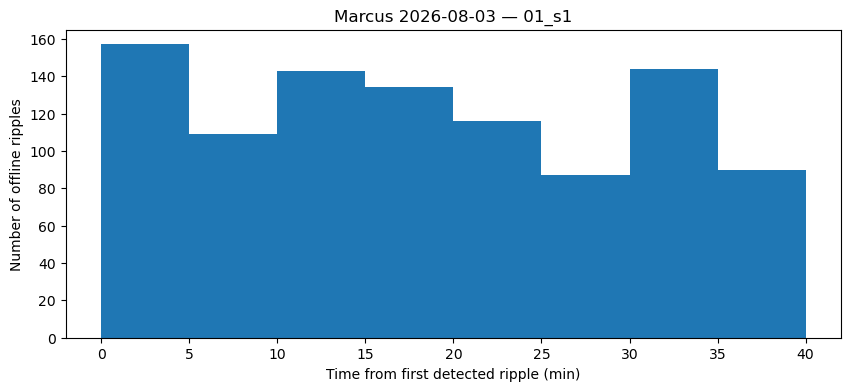

In [55]:
bin_size = 5  # minutes

bins = range(
    0,
    int(ripple_times["time_min"].max()) + bin_size,
    bin_size
)

plt.figure(figsize=(10, 4))

plt.hist(
    ripple_times["time_min"],
    bins=bins
)

plt.xlabel("Time from first detected ripple (min)")
plt.ylabel("Number of offline ripples")
plt.title("Marcus 2026-08-03 — 01_s1")

plt.show()

## Extracting number of ripples in each session

In [56]:
nwb_file_name = "Marcus20260803_.nwb"

sleep_sessions = [
    "01_s1",
    "03_s2",
    "05_s3",
    "07_s4",
    "09_s5",
]

results = []

for session in sleep_sessions:

    ripple_times = (
        sgrip.RippleTimesV1()
        & {
            "nwb_file_name": nwb_file_name,
            "target_interval_list_name": session,
            "ripple_param_name": "default_trodes",
        }
    ).fetch1_dataframe()

    results.append({
        "session": session,
        "n_ripples": len(ripple_times),
    })

ripple_counts = pd.DataFrame(results)

ripple_counts

,session,n_ripples
0,01_s1,980
1,03_s2,1707
2,05_s3,2692
3,07_s4,1522
4,09_s5,2025


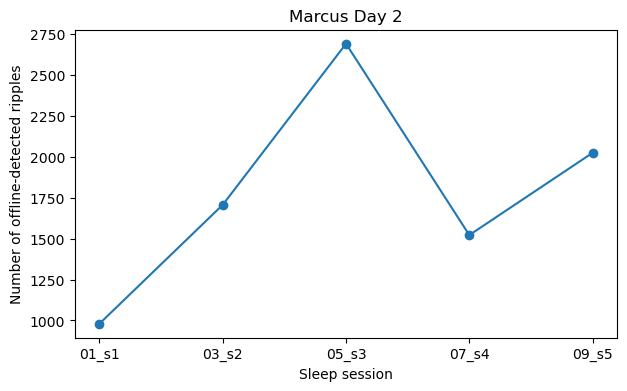

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))

plt.plot(
    ripple_counts["session"],
    ripple_counts["n_ripples"],
    marker="o"
)

plt.xlabel("Sleep session")
plt.ylabel("Number of offline-detected ripples")
plt.title("Marcus Day 2")

plt.show()

Seeing an increase through out the sessions, but this could be due to difference in recording times? so doing a ripple rate

In [58]:
import pandas as pd

nwb_file_name = "Marcus20260802_.nwb"

sleep_sessions = [
    "01_s1",
    "03_s2",
    "05_s3",
    "07_s4",
    "09_s5",
    "11_s6"
]

results = []

for session in sleep_sessions:

    ripple_times = (
        sgrip.RippleTimesV1()
        & {
            "nwb_file_name": nwb_file_name,
            "target_interval_list_name": session,
            "ripple_param_name": "default_trodes",
        }
    ).fetch1_dataframe()

    n_ripples = len(ripple_times)

    first_ripple = ripple_times["start_time"].min()
    last_ripple = ripple_times["end_time"].max()

    duration_sec = last_ripple - first_ripple
    duration_min = duration_sec / 60

    ripple_rate = n_ripples / duration_min

    results.append({
        "session": session,
        "n_ripples": n_ripples,
        "duration_min": duration_min,
        "ripples_per_min": ripple_rate,
    })

ripple_summary = pd.DataFrame(results)

ripple_summary

,session,n_ripples,duration_min,ripples_per_min
0,01_s1,1016,40.097557,25.338202
1,03_s2,1366,39.901656,34.234168
2,05_s3,1821,39.930693,45.604016
3,07_s4,2058,39.899987,51.578964
4,09_s5,2038,39.891656,51.088378
5,11_s6,1466,39.891784,36.749421


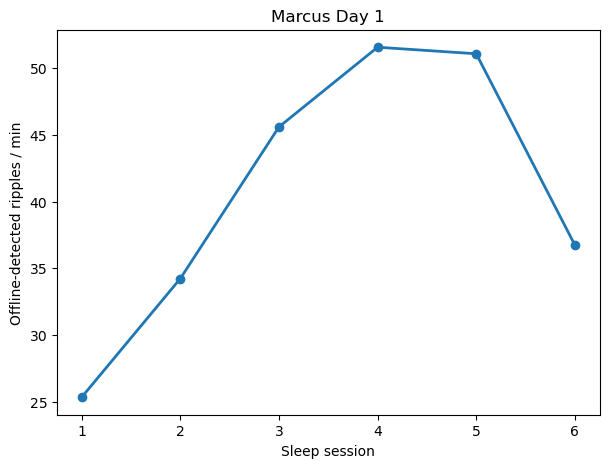

In [59]:
import matplotlib.pyplot as plt

ripple_summary["session_number"] = [1, 2, 3, 4, 5, 6]

plt.figure(figsize=(7, 5))

plt.plot(
    ripple_summary["session_number"],
    ripple_summary["ripples_per_min"],
    marker="o",
    linewidth=2
)

plt.xlabel("Sleep session")
plt.ylabel("Offline-detected ripples / min")
plt.title("Marcus Day 1")

plt.xticks([1, 2, 3, 4, 5, 6])

plt.show()
ripple_summary_day2 = ripple_summary.copy()

Combining 3 days of data 

In [60]:
ripple_summary_day1["day"] = 1
ripple_summary_day2["day"] = 2
ripple_summary_day3["day"] = 3

In [61]:
all_days = pd.concat(
    [
        ripple_summary_day1,
        ripple_summary_day2,
        ripple_summary_day3
    ],
    ignore_index=True
)

all_days

,session,n_ripples,duration_min,ripples_per_min,session_number,day
0,01_s1,913,39.894627,22.885287,1,1
1,03_s2,1216,39.994444,30.404223,2,1
2,05_s3,1462,39.910063,36.632365,3,1
3,07_s4,1793,39.938966,44.893501,4,1
4,09_s5,1737,39.835102,43.604758,5,1
5,11_s6,1547,40.478981,38.217365,6,1
6,01_s1,1016,40.097557,25.338202,1,2
7,03_s2,1366,39.901656,34.234168,2,2
8,05_s3,1821,39.930693,45.604016,3,2
9,07_s4,2058,39.899987,51.578964,4,2


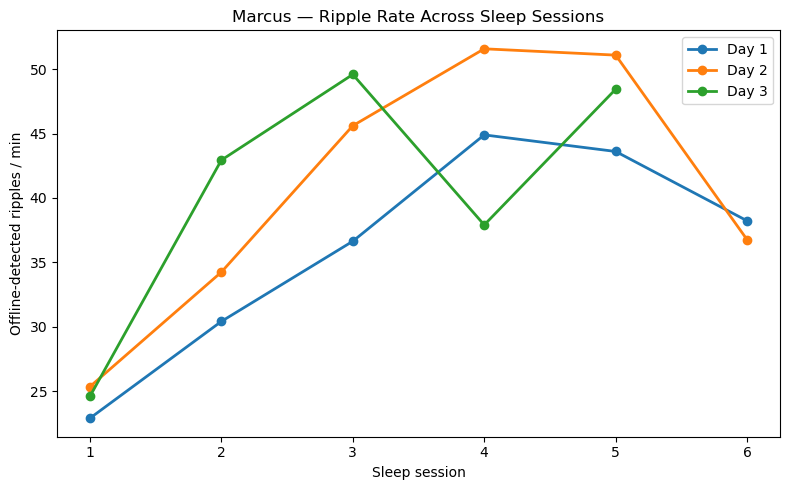

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for day in [1, 2, 3]:

    day_data = all_days[
        all_days["day"] == day
    ].sort_values("session_number")

    plt.plot(
        day_data["session_number"],
        day_data["ripples_per_min"],
        marker="o",
        linewidth=2,
        label=f"Day {day}"
    )

plt.xlabel("Sleep session")
plt.ylabel("Offline-detected ripples / min")
plt.title("Marcus — Ripple Rate Across Sleep Sessions")

plt.xticks([1, 2, 3, 4, 5, 6])
plt.legend()
plt.tight_layout()

plt.show()

In [63]:
condition_map = {
    (1, 1): "No opto",
    (1, 2): "On-time",
    (1, 3): "On-time",
    (1, 4): "On-time",
    (1, 5): "On-time",
    (1, 6): "On-time",

    (2, 1): "No opto",
    (2, 2): "On-time",
    (2, 3): "Delay",
    (2, 4): "Delay",
    (2, 5): "Delay",
    (2, 6): "Delay",

    (3, 1): "No opto",
    (3, 2): "Delay",
    (3, 3): "No opto",
    (3, 4): "On-time",
    (3, 5): "No opto",
}

all_days["condition"] = [
    condition_map[(day, session)]
    for day, session in zip(
        all_days["day"],
        all_days["session_number"]
    )
]

all_days[[
    "day",
    "session_number",
    "session",
    "condition",
    "ripples_per_min"
]]

,day,session_number,session,condition,ripples_per_min
0,1,1,01_s1,No opto,22.885287
1,1,2,03_s2,On-time,30.404223
2,1,3,05_s3,On-time,36.632365
3,1,4,07_s4,On-time,44.893501
4,1,5,09_s5,On-time,43.604758
5,1,6,11_s6,On-time,38.217365
6,2,1,01_s1,No opto,25.338202
7,2,2,03_s2,On-time,34.234168
8,2,3,05_s3,Delay,45.604016
9,2,4,07_s4,Delay,51.578964


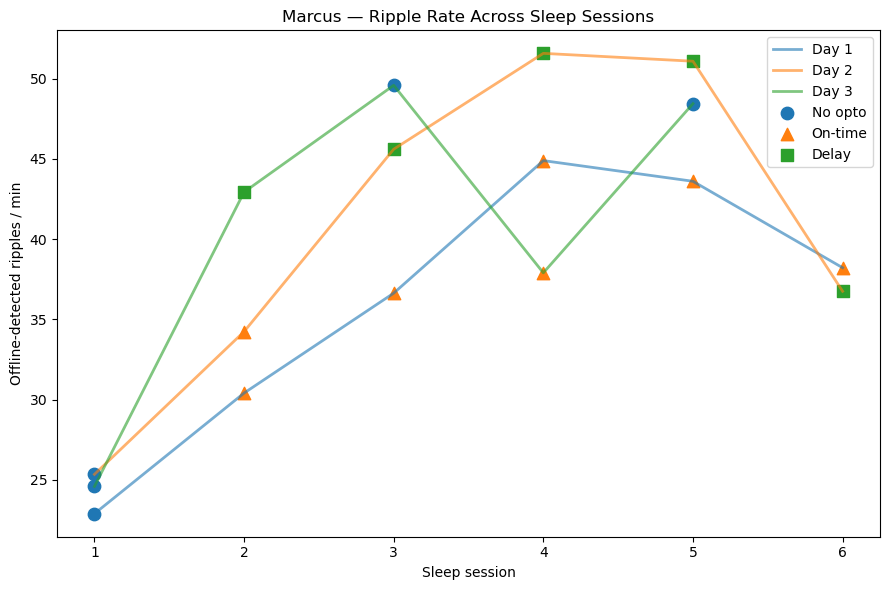

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

# Plot the day trajectories
for day in [1, 2, 3]:

    day_data = (
        all_days[all_days["day"] == day]
        .sort_values("session_number")
    )

    plt.plot(
        day_data["session_number"],
        day_data["ripples_per_min"],
        linewidth=2,
        alpha=0.6,
        label=f"Day {day}"
    )

# Plot condition-specific markers
marker_dict = {
    "No opto": "o",
    "On-time": "^",
    "Delay": "s"
}

for condition, marker in marker_dict.items():

    d = all_days[
        all_days["condition"] == condition
    ]

    plt.scatter(
        d["session_number"],
        d["ripples_per_min"],
        marker=marker,
        s=80,
        label=condition
    )

plt.xlabel("Sleep session")
plt.ylabel("Offline-detected ripples / min")
plt.title("Marcus — Ripple Rate Across Sleep Sessions")

plt.xticks([1, 2, 3, 4, 5, 6])

plt.legend()
plt.tight_layout()
plt.show()

## Question 2 How much the animal moved during offline detected SWR

In [65]:
sgrip.RippleTimesV1() & {"nwb_file_name": 'Marcus20260801_.nwb'}

lfp_merge_id,filter_name descriptive name of this filter,filter_sampling_rate sampling rate for this filter,nwb_file_name name of the NWB file,target_interval_list_name descriptive name of this interval list,lfp_band_sampling_rate the sampling rate for this band,group_name,ripple_param_name a name for this set of parameters,pos_merge_id,analysis_file_name name of the file,ripple_times_object_id
008bb4aa-5cc4-3b06-3ecc-7b1185c057b7,Ripple 150-250 Hz,1000,Marcus20260801_.nwb,01_s1,1000,Ripple Detection Channels,default_trodes,f2e04a63-27bf-c5de-4d78-ed9eefa942df,Marcus20260801_QENAZUYNXH.nwb,14215ffb-0413-4997-83ca-986a7c01378e
12d3a444-fcb7-e9f0-be8d-a1a8129ff7d7,Ripple 150-250 Hz,1000,Marcus20260801_.nwb,05_s3,1000,Ripple Detection Channels,default_trodes,b22a600d-c286-d89f-e1e8-e6f22c87e3ff,Marcus20260801_QRSQNWW9UH.nwb,ddc5dd4d-6d95-485f-a871-8478d6d9ef17
4d9dba5b-81d8-a28d-04ad-2503ac95db58,Ripple 150-250 Hz,1000,Marcus20260801_.nwb,11_s6,1000,Ripple Detection Channels,default_trodes,7024f863-c0f7-abfc-b986-e95ceb19df0c,Marcus20260801_SZOA4Z22B9.nwb,f6891e9d-9e83-4b0e-a0ea-721676e4ab69
82600247-a4a6-d0e5-1930-4a343baf3649,Ripple 150-250 Hz,1000,Marcus20260801_.nwb,03_s2,1000,Ripple Detection Channels,default_trodes,57c27e50-ebc4-d3d2-36e0-89ef8bf5d1e0,Marcus20260801_GZUILVW6JW.nwb,bef4ec68-f299-449b-9f31-ce107a577417
c4d490cf-a82b-7ac9-99c9-78344fc1dce9,Ripple 150-250 Hz,1000,Marcus20260801_.nwb,09_s5,1000,Ripple Detection Channels,default_trodes,a9be6fdd-747e-6d4a-7ef3-bf7cf2dacc4d,Marcus20260801_0X85Q5CIXQ.nwb,9ec0a26f-d452-4ced-9ccb-6eb4b403cc80
e41b86eb-3cf0-9571-4605-97f1a9f37c2f,Ripple 150-250 Hz,1000,Marcus20260801_.nwb,07_s4,1000,Ripple Detection Channels,default_trodes,163e77fa-5f99-adcb-b33d-686ce4598de9,Marcus20260801_1KBT7W0VD8.nwb,6f5496e4-39da-4535-a84f-f59fdb1c4362


In [66]:
lfp_band_key = {'lfp_merge_id': '008bb4aa-5cc4-3b06-3ecc-7b1185c057b7',
 'filter_name': 'Ripple 150-250 Hz',
 'filter_sampling_rate': 1000,
 'nwb_file_name': 'Marcus20260801_.nwb',
 'target_interval_list_name': '01_s1',
 'lfp_band_sampling_rate': 1000,
 'group_name': 'Ripple Detection Channels'}

In [67]:
rip_sel_key = (sgrip.RippleLFPSelection & lfp_band_key).fetch1("KEY")

In [68]:
interval = rip_sel_key["target_interval_list_name"]

ripple_times = (
    sgrip.RippleTimesV1()
    & {
        "nwb_file_name": 'Marcus20260801_.nwb',
        "target_interval_list_name": interval,
        "ripple_param_name": "default_trodes",
    }
).fetch1_dataframe()
ripple_times

,start_time,end_time,duration,max_thresh,mean_zscore,median_zscore,max_zscore,min_zscore,area,total_energy,speed_at_start,speed_at_end,max_speed,min_speed,median_speed,mean_speed
id,,,,,,,,,,,,,,,,
0,1.785604e+09,1.785604e+09,0.057000,2.239953,1.469934,1.081589,3.971768,0.010617,0.085228,0.212975,0.946931,0.941886,0.952001,0.941886,0.949881,0.949160
1,1.785604e+09,1.785604e+09,0.376004,4.460993,2.495914,2.187983,8.124981,0.005748,0.940940,3.401446,0.797835,3.492027,9.898428,0.797835,5.094578,5.473487
2,1.785604e+09,1.785604e+09,0.054001,3.137118,1.692466,1.433523,3.551853,0.036496,0.093004,0.248775,3.831464,3.262523,3.831464,3.262523,3.585889,3.573581
3,1.785604e+09,1.785604e+09,0.059000,3.066296,1.840826,1.620394,4.643156,0.015529,0.110408,0.344158,3.627672,2.593817,3.627672,1.176145,1.894959,2.063797
4,1.785604e+09,1.785604e+09,0.043000,2.714294,2.310967,1.864387,4.834000,0.019716,0.101601,0.325540,2.489688,2.612254,2.612254,2.458262,2.478233,2.498222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
908,1.785606e+09,1.785606e+09,0.091001,3.513859,1.825537,1.159270,6.433349,0.094538,0.167849,0.596364,2.526854,2.115673,2.842916,2.115673,2.688125,2.628005
909,1.785606e+09,1.785606e+09,0.230002,2.967671,1.520309,0.812854,5.101378,0.011370,0.351177,1.038478,3.811734,3.660721,3.811734,2.657864,3.221838,3.222004
910,1.785606e+09,1.785606e+09,0.056000,2.538434,1.880782,2.230190,3.448218,0.004744,0.107195,0.265485,1.378875,1.455486,1.478598,1.378875,1.463908,1.453864


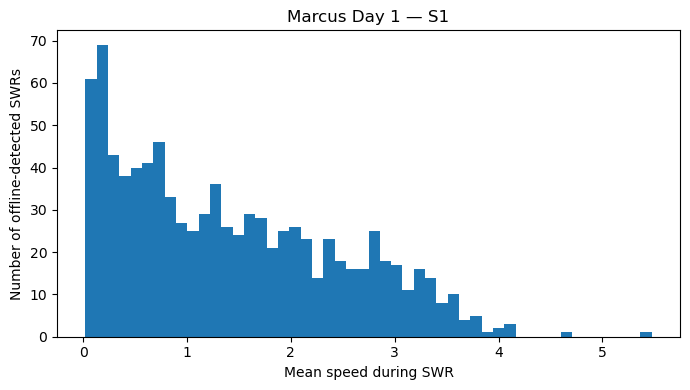

In [69]:
plt.figure(figsize=(7, 4))

plt.hist(
    ripple_times["mean_speed"],
    bins=50
)

plt.xlabel("Mean speed during SWR")
plt.ylabel("Number of offline-detected SWRs")
plt.title("Marcus Day 1 — S1")

plt.tight_layout()
plt.show()

In [70]:
speed_threshold = 4  # cm/s

ripple_times["moving"] = (
    ripple_times["mean_speed"] > speed_threshold
)

In [71]:
n_total = len(ripple_times)
n_moving = ripple_times["moving"].sum()
n_not_moving = n_total - n_moving

percent_moving = (n_moving / n_total) * 100

print("Total offline SWRs:", n_total)
print("Moving SWRs:", n_moving)
print("Not moving SWRs:", n_not_moving)
print(f"Percent moving: {percent_moving:.2f}%")

Total offline SWRs: 913
Moving SWRs: 5
Not moving SWRs: 908
Percent moving: 0.55%


In [72]:
ripple_times["movement_any"] = (
    ripple_times["max_speed"] > speed_threshold
)

n_movement_any = ripple_times["movement_any"].sum()

print("SWRs with max speed > 4 cm/s:", n_movement_any)
print(
    f"Percent: {100 * n_movement_any / len(ripple_times):.2f}%"
)

SWRs with max speed > 4 cm/s: 9
Percent: 0.99%


In [73]:
def calculate_movement_by_session(
    nwb_file_name,
    sleep_sessions,
    day,
    speed_threshold=4
):
    
    results = []

    for session_number, session in enumerate(sleep_sessions, start=1):

        ripple_times = (
            sgrip.RippleTimesV1()
            & {
                "nwb_file_name": nwb_file_name,
                "target_interval_list_name": session,
                "ripple_param_name": "default_trodes",
            }
        ).fetch1_dataframe()

        # Total number of offline SWRs
        n_total = len(ripple_times)

        # Movement based on mean speed > 4 cm/s
        moving = ripple_times["mean_speed"] > speed_threshold
        n_moving = moving.sum()

        percent_moving = 100 * n_moving / n_total

        results.append({
            "day": day,
            "session_number": session_number,
            "session": session,
            "n_total": n_total,
            "n_moving": n_moving,
            "percent_moving": percent_moving,
        })

    return pd.DataFrame(results)

In [74]:
day1_sessions = [
    "01_s1",
    "03_s2",
    "05_s3",
    "07_s4",
    "09_s5",
    "11_s6",
]

movement_day1 = calculate_movement_by_session(
    "Marcus20260801_.nwb",
    day1_sessions,
    day=1
)

movement_day1

,day,session_number,session,n_total,n_moving,percent_moving
0,1,1,01_s1,913,5,0.547645
1,1,2,03_s2,1216,2,0.164474
2,1,3,05_s3,1462,1,0.068399
3,1,4,07_s4,1793,0,0.000000
4,1,5,09_s5,1737,1,0.057571
5,1,6,11_s6,1547,0,0.000000


In [75]:
day2_sessions = [
    "01_s1",
    "03_s2",
    "05_s3",
    "07_s4",
    "09_s5",
    "11_s6",
]

movement_day2 = calculate_movement_by_session(
    "Marcus20260802_.nwb",
    day2_sessions,
    day=2
)

movement_day2

,day,session_number,session,n_total,n_moving,percent_moving
0,2,1,01_s1,1016,2,0.196850
1,2,2,03_s2,1366,1,0.073206
2,2,3,05_s3,1821,1,0.054915
3,2,4,07_s4,2058,2,0.097182
4,2,5,09_s5,2038,0,0.000000
5,2,6,11_s6,1466,1,0.068213


In [76]:
day3_sessions = [
    "01_s1",
    "03_s2",
    "05_s3",
    "07_s4",
    "09_s5",
]

movement_day3 = calculate_movement_by_session(
    "Marcus20260803_.nwb",
    day3_sessions,
    day=3
)

movement_day3

,day,session_number,session,n_total,n_moving,percent_moving
0,3,1,01_s1,980,0,0.000000
1,3,2,03_s2,1707,1,0.058582
2,3,3,05_s3,2692,1,0.037147
3,3,4,07_s4,1522,3,0.197109
4,3,5,09_s5,2025,0,0.000000


In [77]:
movement_all_days = pd.concat(
    [
        movement_day1,
        movement_day2,
        movement_day3
    ],
    ignore_index=True
)

movement_all_days

,day,session_number,session,n_total,n_moving,percent_moving
0,1,1,01_s1,913,5,0.547645
1,1,2,03_s2,1216,2,0.164474
2,1,3,05_s3,1462,1,0.068399
3,1,4,07_s4,1793,0,0.000000
4,1,5,09_s5,1737,1,0.057571
5,1,6,11_s6,1547,0,0.000000
6,2,1,01_s1,1016,2,0.196850
7,2,2,03_s2,1366,1,0.073206
8,2,3,05_s3,1821,1,0.054915
9,2,4,07_s4,2058,2,0.097182


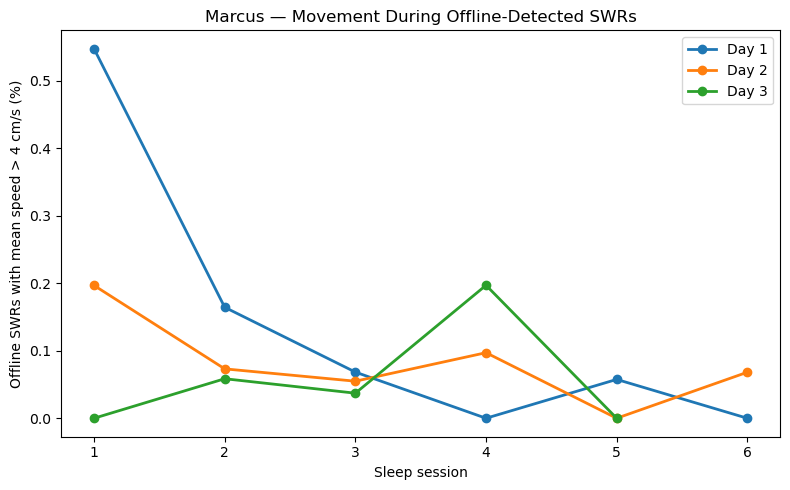

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for day in [1, 2, 3]:

    d = movement_all_days[
        movement_all_days["day"] == day
    ].sort_values("session_number")

    plt.plot(
        d["session_number"],
        d["percent_moving"],
        marker="o",
        linewidth=2,
        label=f"Day {day}"
    )

plt.xlabel("Sleep session")
plt.ylabel("Offline SWRs with mean speed > 4 cm/s (%)")
plt.title("Marcus — Movement During Offline-Detected SWRs")

plt.xticks([1, 2, 3, 4, 5, 6])

plt.legend()
plt.tight_layout()

plt.show()

## Question 3 Are there differences in SWR amplitude or duration across the day or across days of learning?

In [79]:
def get_ripple_properties(
    nwb_file_name,
    sleep_sessions,
    day
):

    all_ripples = []

    for session_number, session in enumerate(sleep_sessions, start=1):

        ripple_times = (
            sgrip.RippleTimesV1()
            & {
                "nwb_file_name": nwb_file_name,
                "target_interval_list_name": session,
                "ripple_param_name": "default_trodes",
            }
        ).fetch1_dataframe()

        # Keep information about where each ripple came from
        ripple_times = ripple_times.copy()

        ripple_times["day"] = day
        ripple_times["session_number"] = session_number
        ripple_times["session"] = session

        # Convert seconds to milliseconds
        ripple_times["duration_ms"] = (
            ripple_times["duration"] * 1000
        )

        all_ripples.append(ripple_times)

    return pd.concat(
        all_ripples,
        ignore_index=True
    )

In [80]:
day1_sessions = [
    "01_s1",
    "03_s2",
    "05_s3",
    "07_s4",
    "09_s5",
    "11_s6",
]

ripples_day1 = get_ripple_properties(
    "Marcus20260801_.nwb",
    day1_sessions,
    day=1
)
ripples_day1

,start_time,end_time,duration,max_thresh,mean_zscore,median_zscore,max_zscore,min_zscore,area,total_energy,speed_at_start,speed_at_end,max_speed,min_speed,median_speed,mean_speed,day,session_number,session,duration_ms
0,1.785604e+09,1.785604e+09,0.057000,2.239953,1.469934,1.081589,3.971768,0.010617,0.085228,0.212975,0.946931,0.941886,0.952001,0.941886,0.949881,0.949160,1,1,01_s1,57.000399
1,1.785604e+09,1.785604e+09,0.376004,4.460993,2.495914,2.187983,8.124981,0.005748,0.940940,3.401446,0.797835,3.492027,9.898428,0.797835,5.094578,5.473487,1,1,01_s1,376.003981
2,1.785604e+09,1.785604e+09,0.054001,3.137118,1.692466,1.433523,3.551853,0.036496,0.093004,0.248775,3.831464,3.262523,3.831464,3.262523,3.585889,3.573581,1,1,01_s1,54.000616
3,1.785604e+09,1.785604e+09,0.059000,3.066296,1.840826,1.620394,4.643156,0.015529,0.110408,0.344158,3.627672,2.593817,3.627672,1.176145,1.894959,2.063797,1,1,01_s1,59.000492
4,1.785604e+09,1.785604e+09,0.043000,2.714294,2.310967,1.864387,4.834000,0.019716,0.101601,0.325540,2.489688,2.612254,2.612254,2.458262,2.478233,2.498222,1,1,01_s1,43.000221
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8663,1.785627e+09,1.785627e+09,0.083001,2.291287,1.898273,2.089168,3.269854,0.074267,0.159374,0.365969,0.369614,0.440958,0.440958,0.369614,0.396969,0.400051,1,6,11_s6,83.001137
8664,1.785627e+09,1.785627e+09,0.135002,2.937533,1.801769,2.066807,3.397733,0.048014,0.244973,0.594646,0.298469,0.191584,0.298469,0.037392,0.136663,0.144058,1,6,11_s6,135.001659
8665,1.785627e+09,1.785627e+09,0.115001,3.663902,2.163915,2.225046,4.061750,0.097059,0.250915,0.699503,0.298499,0.195599,0.298499,0.195599,0.241606,0.243855,1,6,11_s6,115.001440
8666,1.785627e+09,1.785627e+09,0.070001,2.076950,1.871742,2.013648,3.176449,0.002542,0.132882,0.294338,1.495445,2.599186,2.599186,1.495445,2.002969,2.020536,1,6,11_s6,70.000887


In [81]:
day2_sessions = [
    "01_s1",
    "03_s2",
    "05_s3",
    "07_s4",
    "09_s5",
    "11_s6",
]

ripples_day2 = get_ripple_properties(
    "Marcus20260802_.nwb",
    day2_sessions,
    day=2
)
ripples_day2

,start_time,end_time,duration,max_thresh,mean_zscore,median_zscore,max_zscore,min_zscore,area,total_energy,speed_at_start,speed_at_end,max_speed,min_speed,median_speed,mean_speed,day,session_number,session,duration_ms
0,1.785690e+09,1.785690e+09,0.063802,5.762066,3.356077,2.260494,8.837974,0.002269,0.217361,1.270507,3.423382,1.588491,3.423382,0.509012,1.187457,1.441543,2,1,01_s1,63.801527
1,1.785690e+09,1.785690e+09,0.079268,4.059262,1.905623,0.958151,6.075356,0.000543,0.152863,0.586368,1.733793,1.522331,1.733793,1.522331,1.607851,1.614341,2,1,01_s1,79.268217
2,1.785690e+09,1.785690e+09,0.051234,3.191713,2.136517,1.854300,4.724625,0.014329,0.111489,0.356866,2.933436,0.611447,2.933436,0.162710,1.229314,1.335156,2,1,01_s1,51.234484
3,1.785690e+09,1.785690e+09,0.077335,3.061769,1.638683,0.899660,4.067426,0.007978,0.128293,0.355649,0.212612,0.305231,0.305231,0.212612,0.259392,0.259212,2,1,01_s1,77.334881
4,1.785690e+09,1.785690e+09,0.124703,5.797009,2.709961,2.094801,6.514602,0.077100,0.340472,1.415148,0.068935,0.049979,0.118694,0.049979,0.100354,0.094741,2,1,01_s1,124.702692
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9760,1.785712e+09,1.785712e+09,0.090868,2.618534,1.529566,1.407547,4.096090,0.054975,0.140396,0.352494,0.189855,1.643421,1.643421,0.146129,0.949643,0.906800,2,6,11_s6,90.867519
9761,1.785712e+09,1.785712e+09,0.106334,2.191102,1.354241,1.111893,3.482228,0.033978,0.145242,0.273438,2.018091,1.944211,2.081864,1.944211,2.058322,2.047097,2,6,11_s6,106.334209
9762,1.785712e+09,1.785712e+09,0.062834,2.255077,1.448360,0.747322,4.452627,0.004104,0.092390,0.258432,0.166826,0.278285,0.279140,0.166826,0.253387,0.243259,2,6,11_s6,62.833786
9763,1.785712e+09,1.785712e+09,0.148868,2.460467,1.307306,1.113862,4.284901,0.008050,0.195797,0.406813,1.545367,2.837611,2.837611,1.545367,2.156442,2.170005,2,6,11_s6,148.868322


In [82]:
day3_sessions = [
    "01_s1",
    "03_s2",
    "05_s3",
    "07_s4",
    "09_s5",
]

ripples_day3 = get_ripple_properties(
    "Marcus20260803_.nwb",
    day3_sessions,
    day=3
)
ripples_day3

,start_time,end_time,duration,max_thresh,mean_zscore,median_zscore,max_zscore,min_zscore,area,total_energy,speed_at_start,speed_at_end,max_speed,min_speed,median_speed,mean_speed,day,session_number,session,duration_ms
0,1.785780e+09,1.785780e+09,0.120001,2.066704,1.394917,1.384835,3.783726,0.038718,0.168741,0.338989,2.375658,1.957846,2.375658,0.629370,1.497180,1.443860,3,1,01_s1,120.001316
1,1.785780e+09,1.785780e+09,0.105001,2.338925,1.317668,1.092244,4.793311,0.008358,0.139640,0.341967,2.890780,2.187050,3.069819,2.187050,2.926486,2.807544,3,1,01_s1,105.000734
2,1.785780e+09,1.785780e+09,0.054000,3.845777,2.559634,2.452263,4.567889,0.075428,0.140697,0.472653,2.703820,1.774367,2.703820,1.774367,2.288746,2.272578,3,1,01_s1,54.000378
3,1.785780e+09,1.785780e+09,0.060001,2.672398,2.135153,2.311204,4.490575,0.054323,0.130189,0.378694,0.226956,0.592453,0.592453,0.220838,0.297549,0.336308,3,1,01_s1,60.000658
4,1.785780e+09,1.785780e+09,0.078001,2.103302,1.346421,1.193828,2.809148,0.002258,0.106343,0.197313,1.397366,2.319484,2.319484,1.397366,1.948223,1.919738,3,1,01_s1,78.000784
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8921,1.785800e+09,1.785800e+09,0.053000,2.644074,1.795385,1.002031,4.504583,0.032588,0.096888,0.287168,0.131010,0.090514,0.131010,0.090514,0.108662,0.109374,3,5,09_s5,53.000450
8922,1.785800e+09,1.785800e+09,0.174002,2.195663,1.676817,1.631123,3.612698,0.032538,0.293382,0.630219,0.479147,0.310092,0.479147,0.310092,0.388167,0.390931,3,5,09_s5,174.001932
8923,1.785800e+09,1.785800e+09,0.092001,3.040507,1.882310,1.891889,3.685911,0.004593,0.174962,0.421511,0.485542,0.396685,0.485542,0.396685,0.435026,0.437354,3,5,09_s5,92.000961
8924,1.785800e+09,1.785800e+09,0.074001,3.131565,1.814764,1.577175,3.920792,0.050686,0.136049,0.354810,0.475363,0.647608,0.647608,0.475363,0.563762,0.562837,3,5,09_s5,74.000597


In [83]:
all_ripples = pd.concat(
    [
        ripples_day1,
        ripples_day2,
        ripples_day3
    ],
    ignore_index=True
)

In [84]:
all_ripples["duration_ms"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
)

count    27359.000000
mean       129.382723
std         81.322816
min         23.000240
1%          34.000397
5%          46.000242
25%         74.000835
50%        109.001160
75%        162.401915
95%        281.002760
99%        400.004010
max       1978.687525
Name: duration_ms, dtype: float64

In [85]:
all_ripples["max_zscore"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
)

count    27359.000000
mean         4.410094
std          1.306992
min          2.128809
1%           2.421846
5%           2.723482
25%          3.433616
50%          4.173397
75%          5.176522
95%          6.799235
99%          8.191685
max         14.414394
Name: max_zscore, dtype: float64

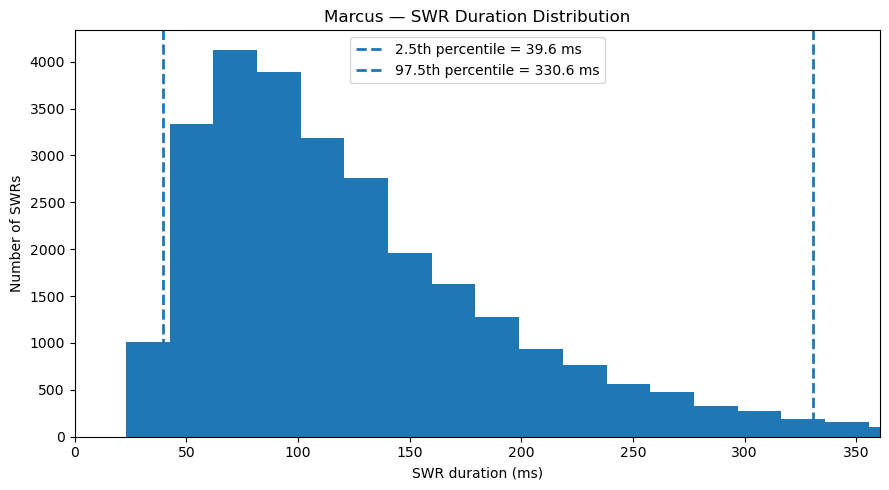

In [86]:
import numpy as np
import matplotlib.pyplot as plt

durations = all_ripples["duration_ms"].dropna()

lower_95 = np.percentile(durations, 2.5)
upper_95 = np.percentile(durations, 97.5)

plt.figure(figsize=(9, 5))

# Plot all data
plt.hist(
    durations,
    bins=100
)

# 95% boundaries
plt.axvline(
    lower_95,
    linestyle="--",
    linewidth=2,
    label=f"2.5th percentile = {lower_95:.1f} ms"
)

plt.axvline(
    upper_95,
    linestyle="--",
    linewidth=2,
    label=f"97.5th percentile = {upper_95:.1f} ms"
)

# Zoom display
plt.xlim(0, upper_95 + 30)

plt.xlabel("SWR duration (ms)")
plt.ylabel("Number of SWRs")
plt.title("Marcus — SWR Duration Distribution")

plt.legend()
plt.tight_layout()
plt.show()

In [88]:
amplitude = all_ripples["max_zscore"].dropna()

2.5th percentile: 2.57
97.5th percentile: 7.43


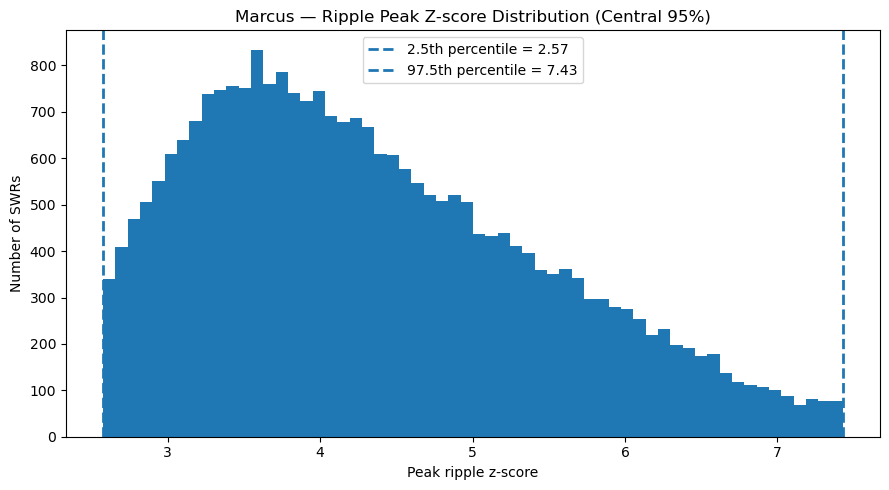

In [89]:
lower_95_amp = np.percentile(amplitude, 2.5)
upper_95_amp = np.percentile(amplitude, 97.5)

print(f"2.5th percentile: {lower_95_amp:.2f}")
print(f"97.5th percentile: {upper_95_amp:.2f}")

plt.figure(figsize=(9, 5))

plt.hist(
    amplitude,
    bins=60,
    range=(lower_95_amp, upper_95_amp)
)

plt.axvline(
    lower_95_amp,
    linestyle="--",
    linewidth=2,
    label=f"2.5th percentile = {lower_95_amp:.2f}"
)

plt.axvline(
    upper_95_amp,
    linestyle="--",
    linewidth=2,
    label=f"97.5th percentile = {upper_95_amp:.2f}"
)

plt.xlabel("Peak ripple z-score")
plt.ylabel("Number of SWRs")
plt.title("Marcus — Ripple Peak Z-score Distribution (Central 95%)")

plt.legend()
plt.tight_layout()
plt.show()

# Duration across sessions

In [90]:
duration_summary = (
    all_ripples
    .groupby(["day", "session_number"])["duration_ms"]
    .agg(
        n="count",
        median="median",
        mean="mean",
        std="std"
    )
    .reset_index()
)

duration_summary

,day,session_number,n,median,mean,std
0,1,1,913,71.000814,82.283426,46.479903
1,1,2,1216,90.000749,109.306995,68.720177
2,1,3,1462,102.001190,120.358972,70.550299
3,1,4,1793,126.001358,146.776941,83.841206
4,1,5,1737,113.000870,133.412864,76.716578
5,1,6,1547,109.001637,130.571793,80.779231
6,2,1,1016,77.335119,93.855239,60.369104
7,2,2,1366,112.617135,135.486059,82.946356
8,2,3,1821,116.967678,136.335650,87.966793
9,2,4,2058,119.868040,137.604879,101.275583


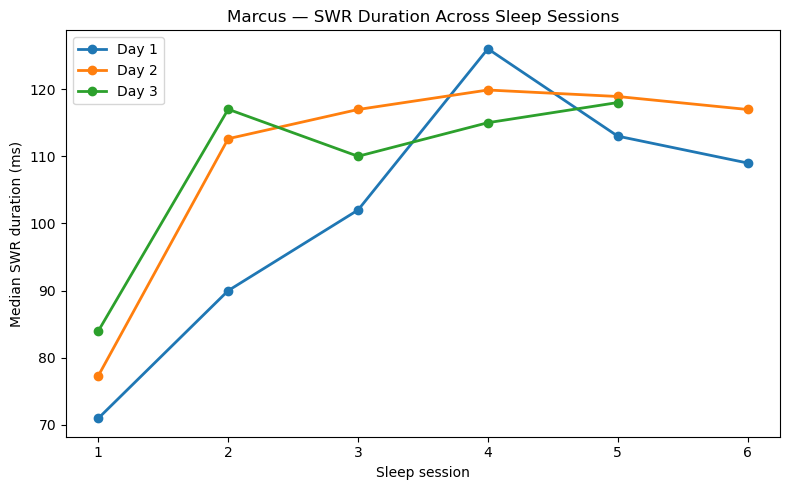

In [91]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for day in [1, 2, 3]:

    d = duration_summary[
        duration_summary["day"] == day
    ].sort_values("session_number")

    plt.plot(
        d["session_number"],
        d["median"],
        marker="o",
        linewidth=2,
        label=f"Day {day}"
    )

plt.xlabel("Sleep session")
plt.ylabel("Median SWR duration (ms)")
plt.title("Marcus — SWR Duration Across Sleep Sessions")

plt.xticks([1, 2, 3, 4, 5, 6])

plt.legend()
plt.tight_layout()
plt.show()

In [92]:
amplitude_summary = (
    all_ripples
    .groupby(["day", "session_number"])["max_zscore"]
    .agg(
        n="count",
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        mean="mean",
        std="std"
    )
    .reset_index()
)

amplitude_summary["IQR"] = (
    amplitude_summary["q75"] -
    amplitude_summary["q25"]
)

amplitude_summary

,day,session_number,n,median,q25,q75,mean,std,IQR
0,1,1,913,3.927032,3.321802,4.797590,4.209212,1.285852,1.475789
1,1,2,1216,4.132720,3.387546,5.402215,4.547519,1.572366,2.014669
2,1,3,1462,4.182286,3.401940,5.356914,4.462233,1.315098,1.954974
3,1,4,1793,4.167837,3.437862,5.068089,4.318883,1.141367,1.630227
4,1,5,1737,4.205140,3.455084,5.122553,4.369839,1.182223,1.667469
5,1,6,1547,4.242264,3.386453,5.306465,4.470735,1.339991,1.920013
6,2,1,1016,4.008516,3.340063,5.084632,4.416447,1.545118,1.744569
7,2,2,1366,4.330755,3.491684,5.680140,4.700800,1.490569,2.188456
8,2,3,1821,4.177672,3.450642,5.049746,4.313086,1.118451,1.599104
9,2,4,2058,4.107365,3.396011,4.902707,4.233575,1.082589,1.506696


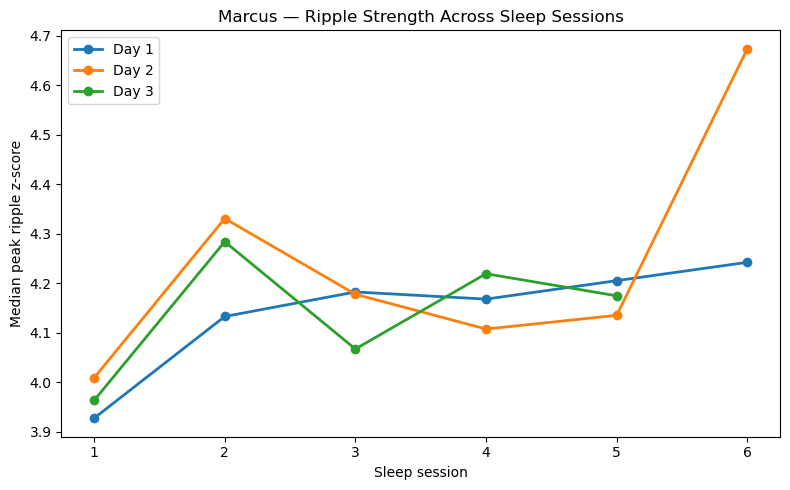

In [93]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for day in [1, 2, 3]:

    d = amplitude_summary[
        amplitude_summary["day"] == day
    ].sort_values("session_number")

    plt.plot(
        d["session_number"],
        d["median"],
        marker="o",
        linewidth=2,
        label=f"Day {day}"
    )

plt.xlabel("Sleep session")
plt.ylabel("Median peak ripple z-score")
plt.title("Marcus — Ripple Strength Across Sleep Sessions")

plt.xticks([1, 2, 3, 4, 5, 6])

plt.legend()
plt.tight_layout()
plt.show()

## On-time ripple detection

In [94]:
from spyglass.spikesorting.analysis.v1.group import SortedSpikesGroup
SortedSpikesGroup & {"nwb_file_name": "Marcus20260801_.nwb"}

nwb_file_name name of the NWB file,unit_filter_params_name,sorted_spikes_group_name
Marcus20260801_.nwb,exclude_all_other,mPFC


In [95]:
from spyglass.spikesorting.analysis.v1.group import SortedSpikesGroup

nwb_file_name = 'Marcus20260801_.nwb'

group_key = {
    "nwb_file_name": nwb_file_name,
    "sorted_spikes_group_name":"mPFC",
}
SortedSpikesGroup & group_key

nwb_file_name name of the NWB file,unit_filter_params_name,sorted_spikes_group_name
Marcus20260801_.nwb,exclude_all_other,mPFC


In [96]:
SortedSpikesGroup.Units & group_key

nwb_file_name name of the NWB file,unit_filter_params_name,sorted_spikes_group_name,spikesorting_merge_id
Marcus20260801_.nwb,exclude_all_other,mPFC,4442fe8e-2379-9601-f336-268481927571
Marcus20260801_.nwb,exclude_all_other,mPFC,558a57ea-48d4-1931-4221-fcf91bc53d41
Marcus20260801_.nwb,exclude_all_other,mPFC,b7d8e9da-2cd1-d0e1-e3b6-b90ec002b4a4
Marcus20260801_.nwb,exclude_all_other,mPFC,cf74deaf-2fa1-626f-6b00-d4ace4d70bc9
Marcus20260801_.nwb,exclude_all_other,mPFC,d9dfcad5-a9bb-0e12-ead9-70d777d6546f
Marcus20260801_.nwb,exclude_all_other,mPFC,f7ac6941-3446-6324-3cca-74fe04d0883c


In [97]:
from spyglass.spikesorting.analysis.v1.group import SortedSpikesGroup
group_key ={'nwb_file_name': 'Marcus20260801_.nwb',
 'sorted_spikes_group_name': 'mPFC'}

In [98]:
# get the complete key
group_key = (SortedSpikesGroup & group_key).fetch1("KEY")
# get the spike data, returns a list of unit spike times
SortedSpikesGroup().fetch_spike_data(group_key)

[15:03:14][WARNING] Spyglass: Missing code for CurationV2
/home/sgao/source/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/backends/hdf5/h5tools.py:620: BrokenLinkWarning: Path to Group altered/broken at /general/devices/MarketTech LuxX+ Red/model
  warnings.warn('Path to Group altered/broken at ' + os.path.join(h5obj.name, k), BrokenLinkWarning)
/home/sgao/source/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/backends/hdf5/h5tools.py:620: BrokenLinkWarning: Path to Group altered/broken at /general/devices/Optical fiber 1/model
  warnings.warn('Path to Group altered/broken at ' + os.path.join(h5obj.name, k), BrokenLinkWarning)
/home/sgao/source/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/backends/hdf5/h5tools.py:620: BrokenLinkWarning: Path to Group altered/broken at /general/devices/Optical fiber 2/model
  warnings.warn('Path to Group altered/broken at ' + os.path.join(h5obj.name, k), BrokenLinkWarning)
/home/sgao/source/miniforge3/envs/spyglass/

[array([1.78560405e+09, 1.78560405e+09, 1.78560405e+09, ...,
        1.78562700e+09, 1.78562700e+09, 1.78562700e+09]),
 array([1.78560405e+09, 1.78560405e+09, 1.78560406e+09, ...,
        1.78562699e+09, 1.78562699e+09, 1.78562699e+09]),
 array([1.78560429e+09, 1.78560430e+09, 1.78560431e+09, ...,
        1.78562675e+09, 1.78562696e+09, 1.78562696e+09]),
 array([1.78560405e+09, 1.78560405e+09, 1.78560405e+09, ...,
        1.78562700e+09, 1.78562700e+09, 1.78562700e+09]),
 array([1.78560405e+09, 1.78560405e+09, 1.78560405e+09, ...,
        1.78562701e+09, 1.78562701e+09, 1.78562701e+09]),
 array([1.78560407e+09, 1.78560407e+09, 1.78560407e+09, ...,
        1.78562696e+09, 1.78562698e+09, 1.78562699e+09]),
 array([1.78560405e+09, 1.78560405e+09, 1.78560405e+09, ...,
        1.78562700e+09, 1.78562701e+09, 1.78562701e+09]),
 array([1.78560405e+09, 1.78560405e+09, 1.78560405e+09, ...,
        1.78562701e+09, 1.78562701e+09, 1.78562701e+09]),
 array([1.78560406e+09, 1.78560406e+09, 1.785604

## Laser trigger time

In [99]:
import numpy as np
import pynwb
import spyglass.common as sgc

#this reads the raw nwb file so we can get laser DIO times
io = pynwb.NWBHDF5IO("/stelmo/nwb/raw/Marcus20260801.nwb", mode="r")
nwbf = io.read()

In [111]:
for epoch_number in range(11):

    epoch_start_time, epoch_stop_time, epoch_name = (
        nwbf.intervals['epochs'][epoch_number].to_numpy()[0]
    )

    print(epoch_number, epoch_name)

0 ['01_s1']
1 ['02_r1']
2 ['03_s2']
3 ['04_r2']
4 ['05_s3']
5 ['06_r3']
6 ['07_s4']
7 ['08_r4']
8 ['09_s5']
9 ['10_r5']
10 ['11_s6']


In [103]:
# Read Marcus raw NWB
import pynwb

io = pynwb.NWBHDF5IO(
    "/stelmo/nwb/raw/Marcus20260801_.nwb",
    mode="r"
)

nwbf = io.read()

# Get the raw Laser time series
laser = (
    nwbf.processing["behavior"]
    .data_interfaces["behavioral_events"]
    .time_series["Laser"]
)

# Show the first 20 raw values and timestamps
print("Data:")
print(laser.data[:20])

print("\nTimestamps:")
print(laser.timestamps[:20])

Data:
[0 0 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1]

Timestamps:
[1.78560405e+09 1.78560655e+09 1.78560785e+09 1.78560786e+09
 1.78560786e+09 1.78560786e+09 1.78560786e+09 1.78560786e+09
 1.78560786e+09 1.78560786e+09 1.78560786e+09 1.78560786e+09
 1.78560786e+09 1.78560786e+09 1.78560786e+09 1.78560786e+09
 1.78560786e+09 1.78560786e+09 1.78560786e+09 1.78560786e+09]


In [105]:
import numpy as np

epoch_number = 2  # 03_s2

# Get epoch boundaries
epoch_start_time, epoch_stop_time, epoch_name = (
    nwbf.intervals["epochs"][epoch_number].to_numpy()[0]
)

# Get raw Laser data
laser = (
    nwbf.processing["behavior"]
    .data_interfaces["behavioral_events"]
    .time_series["Laser"]
)

laser_data = laser.data[:]
laser_timestamps = laser.timestamps[:]

# Restrict to this epoch
mask = (
    (laser_timestamps > epoch_start_time) &
    (laser_timestamps <= epoch_stop_time)
)

laser_data_epoch = laser_data[mask].copy()
laser_timestamps_epoch = laser_timestamps[mask]

# Find rising edges directly from the already-binary signal
rising_edge_idx = np.where(
    np.diff(laser_data_epoch, prepend=0) == 1
)[0]

# Timestamp of every individual laser pulse
pulse_start_times = laser_timestamps_epoch[rising_edge_idx]

# Known stimulation protocol:
# 20 laser pulses = 1 stimulation train
pulses_per_train = 20

# Keep only complete trains
n_complete_trains = len(pulse_start_times) // pulses_per_train

pulse_groups = pulse_start_times[
    :n_complete_trains * pulses_per_train
].reshape(
    n_complete_trains,
    pulses_per_train
)

# First pulse of each 20-pulse train
first_laser_on_times = pulse_groups[:, 0]

print("Epoch:", epoch_number)
print("Name:", epoch_name)
print("Individual laser pulses:", len(pulse_start_times))
print("Complete laser trains:", len(first_laser_on_times))
print("Pulses per train:", pulses_per_train)

Epoch: 2
Name: ['03_s2']
Individual laser pulses: 43380
Complete laser trains: 2169
Pulses per train: 20


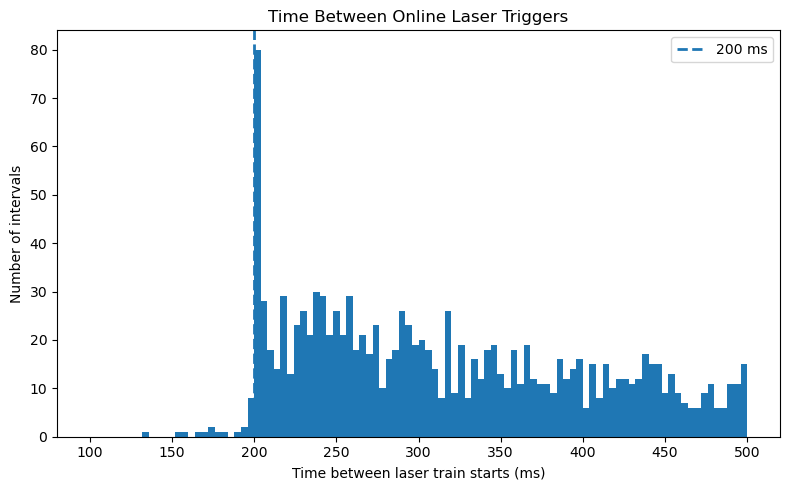

In [102]:
# Start time of each 20-pulse laser train
train_starts = pulse_groups[:, 0]

# Time from one train start to the next
train_gaps = np.diff(train_starts)

# Convert to milliseconds
train_gaps_ms = train_gaps * 1000

plt.figure(figsize=(8, 5))

plt.hist(
    train_gaps_ms,
    bins=100,
    range=(100, 500)
)

plt.axvline(
    200,
    linestyle="--",
    linewidth=2,
    label="200 ms"
)

plt.xlabel("Time between laser train starts (ms)")
plt.ylabel("Number of intervals")
plt.title("Time Between Online Laser Triggers")

plt.legend()
plt.tight_layout()
plt.show()

In [106]:
ripple_times = (
    sgrip.RippleTimesV1()
    & {
        "nwb_file_name": "Marcus20260801_.nwb",
        "target_interval_list_name": "03_s2",
        "ripple_param_name": "default_trodes",
    }
).fetch1_dataframe()

Comparing number of events in online and offline

In [107]:
n_online = len(first_laser_on_times)
n_offline = len(ripple_times)

print("Online events:", n_online)
print("Offline events:", n_offline)

Online events: 2169
Offline events: 1216


In [121]:
nwb_file_name = "Marcus20260801_.nwb"
day2_sessions = {
    2: "03_s2",
    4: "05_s3",
    6: "07_s4",
    8: "09_s5",
    10: "11_s6",
}

results = []

# Raw laser time series
laser = (
    nwbf.processing["behavior"]
    .data_interfaces["behavioral_events"]
    .time_series["Laser"]
)

laser_data = laser.data[:]
laser_timestamps = laser.timestamps[:]

for epoch_number, session in day1_sessions.items():

    # --------------------------
    # ONLINE EVENTS
    # --------------------------

    epoch_start_time, epoch_stop_time, epoch_name = (
        nwbf.intervals["epochs"][epoch_number].to_numpy()[0]
    )

    mask = (
        (laser_timestamps > epoch_start_time) &
        (laser_timestamps <= epoch_stop_time)
    )

    laser_data_epoch = laser_data[mask].copy()
    laser_timestamps_epoch = laser_timestamps[mask]

    # Find OFF -> ON transitions = individual pulse starts
    rising_edge_idx = np.where(
        np.diff(laser_data_epoch, prepend=0) == 1
    )[0]

    pulse_start_times = laser_timestamps_epoch[rising_edge_idx]

    # 20 pulses = one online-triggered laser train
    n_online = len(pulse_start_times) // 20

    # --------------------------
    # OFFLINE EVENTS
    # --------------------------

    ripple_times = (
        sgrip.RippleTimesV1()
        & {
            "nwb_file_name": nwb_file_name,
            "target_interval_list_name": session,
            "ripple_param_name": "default_trodes",
        }
    ).fetch1_dataframe()

    n_offline = len(ripple_times)

    # --------------------------
    # Store
    # --------------------------

    results.append({
        "session": session,
        "online": n_online,
        "offline": n_offline,
    })


day1_detection_counts = pd.DataFrame(results)

day1_detection_counts

,session,online,offline
0,03_s2,2169,1216
1,05_s3,1180,1462
2,07_s4,1364,1793
3,09_s5,1782,1737
4,11_s6,2186,1547


In [122]:
day1_detection_counts["percent_difference"] = (
    abs(
        day1_detection_counts["online"]
        - day1_detection_counts["offline"]
    )
    / day1_detection_counts["offline"]
) * 100

day1_detection_counts

,session,online,offline,percent_difference
0,03_s2,2169,1216,78.371711
1,05_s3,1180,1462,19.288646
2,07_s4,1364,1793,23.926380
3,09_s5,1782,1737,2.590674
4,11_s6,2186,1547,41.305753


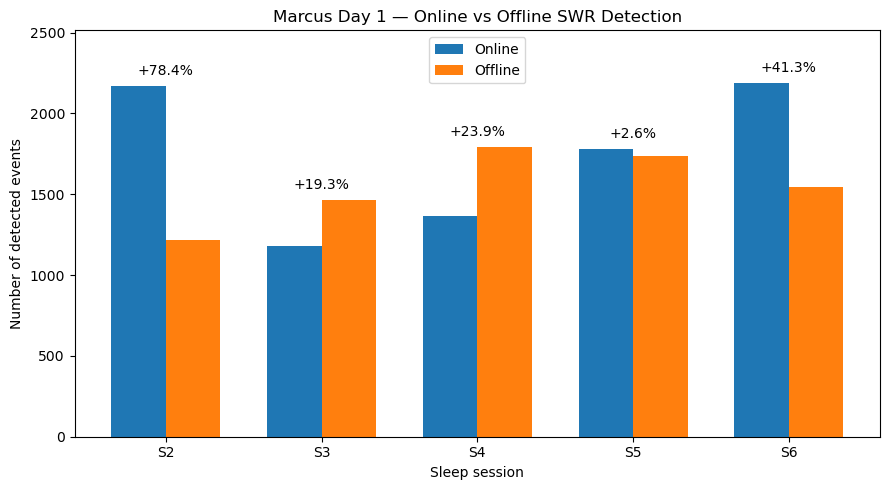

In [123]:
x = np.arange(len(day1_detection_counts))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

bars_online = ax.bar(
    x - width/2,
    day1_detection_counts["online"],
    width,
    label="Online"
)

bars_offline = ax.bar(
    x + width/2,
    day1_detection_counts["offline"],
    width,
    label="Offline"
)

# Add percentage difference above each pair
for i, row in day1_detection_counts.iterrows():

    y = max(row["online"], row["offline"])

    ax.text(
        x[i],
        y + 50,
        f'{row["percent_difference"]:+.1f}%',
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.set_xticks(x)
ax.set_xticklabels(["S2", "S3", "S4", "S5", "S6"])

ax.set_xlabel("Sleep session")
ax.set_ylabel("Number of detected events")
ax.set_title("Marcus Day 1 — Online vs Offline SWR Detection")

ax.legend()

# Give percentage labels some room
ax.set_ylim(
    0,
    max(
        day1_detection_counts["online"].max(),
        day1_detection_counts["offline"].max()
    ) * 1.15
)

plt.tight_layout()
plt.show()

In [109]:
all_days

,session,n_ripples,duration_min,ripples_per_min,session_number,day,condition
0,01_s1,913,39.894627,22.885287,1,1,No opto
1,03_s2,1216,39.994444,30.404223,2,1,On-time
2,05_s3,1462,39.910063,36.632365,3,1,On-time
3,07_s4,1793,39.938966,44.893501,4,1,On-time
4,09_s5,1737,39.835102,43.604758,5,1,On-time
5,11_s6,1547,40.478981,38.217365,6,1,On-time
6,01_s1,1016,40.097557,25.338202,1,2,No opto
7,03_s2,1366,39.901656,34.234168,2,2,On-time
8,05_s3,1821,39.930693,45.604016,3,2,Delay
9,07_s4,2058,39.899987,51.578964,4,2,Delay


Online and Offline time match

In [136]:
offline_day1_s2.head()

,start_time,end_time,duration,max_thresh,mean_zscore,median_zscore,max_zscore,min_zscore,area,total_energy,speed_at_start,speed_at_end,max_speed,min_speed,median_speed,mean_speed
id,,,,,,,,,,,,,,,,
0,1.785608e+09,1.785608e+09,0.079001,2.086048,1.176049,0.751106,3.347718,0.017335,0.094054,0.180912,1.181417,1.396312,1.420020,1.181417,1.385691,1.352280
1,1.785608e+09,1.785608e+09,0.099001,2.824955,2.085930,2.168490,4.601042,0.027714,0.208537,0.579255,1.026987,2.111911,2.111911,1.026987,1.419837,1.477242
2,1.785608e+09,1.785608e+09,0.062001,2.154068,1.767889,1.718060,3.784784,0.123407,0.111227,0.256763,2.666553,3.124519,3.124519,2.666553,2.989315,2.958369
3,1.785608e+09,1.785608e+09,0.134001,2.324629,1.236534,0.721698,3.466847,0.017572,0.166863,0.335773,1.171236,3.699323,3.699323,1.171236,2.393566,2.390729
4,1.785608e+09,1.785608e+09,0.048001,2.293151,1.493871,1.668893,2.577284,0.029654,0.073137,0.142024,1.816234,1.337723,1.816234,1.337723,1.527828,1.545883


In [140]:
online_day1_s2[:10]

array([1.78560786e+09, 1.78560786e+09, 1.78560787e+09, 1.78560788e+09,
       1.78560788e+09, 1.78560789e+09, 1.78560789e+09, 1.78560789e+09,
       1.78560791e+09, 1.78560792e+09])

In [143]:
pulse_groups[:10]

array([[1.78561166e+09, 1.78561166e+09, 1.78561166e+09, 1.78561166e+09,
        1.78561166e+09, 1.78561166e+09, 1.78561166e+09, 1.78561166e+09,
        1.78561166e+09, 1.78561166e+09, 1.78561166e+09, 1.78561166e+09,
        1.78561166e+09, 1.78561166e+09, 1.78561166e+09, 1.78561166e+09,
        1.78561166e+09, 1.78561166e+09, 1.78561166e+09, 1.78561166e+09],
       [1.78561166e+09, 1.78561166e+09, 1.78561166e+09, 1.78561166e+09,
        1.78561166e+09, 1.78561166e+09, 1.78561166e+09, 1.78561166e+09,
        1.78561166e+09, 1.78561166e+09, 1.78561166e+09, 1.78561166e+09,
        1.78561166e+09, 1.78561166e+09, 1.78561166e+09, 1.78561166e+09,
        1.78561166e+09, 1.78561166e+09, 1.78561166e+09, 1.78561166e+09],
       [1.78561166e+09, 1.78561166e+09, 1.78561166e+09, 1.78561166e+09,
        1.78561166e+09, 1.78561166e+09, 1.78561166e+09, 1.78561166e+09,
        1.78561166e+09, 1.78561166e+09, 1.78561166e+09, 1.78561166e+09,
        1.78561166e+09, 1.78561166e+09, 1.78561166e+09, 1.7856

In [ ]:
online_day1_s2[:10]

array([1.78560786e+09, 1.78560786e+09, 1.78560787e+09, 1.78560788e+09,
       1.78560788e+09, 1.78560789e+09, 1.78560789e+09, 1.78560789e+09,
       1.78560791e+09, 1.78560792e+09])

In [144]:
pulse_groups.shape

(1180, 20)

Matching online with offline in time range

In [128]:
# ============================================================
# Marcus Day 1 — Sleep Session 2 (03_s2) — ON-TIME condition
# ============================================================

nwb_file_name = "Marcus20260801_.nwb"
session = "03_s2"

# -------------------------
# OFFLINE ripple detections
# -------------------------
offline_day1_s2 = (
    sgrip.RippleTimesV1()
    & {
        "nwb_file_name": nwb_file_name,
        "target_interval_list_name": session,
        "ripple_param_name": "default_trodes",
    }
).fetch1_dataframe()

# -------------------------
# ONLINE detections
# -------------------------
# first_laser_on_times was extracted from epoch 2,
# which corresponds to 03_s2
online_day1_s2 = first_laser_on_times.copy()


# -------------------------
# Summary
# -------------------------
print("Marcus Day 1")
print("Session:", session)
print("Condition: ON-TIME")

print("\nOFFLINE")
print("Number of events:", len(offline_day1_s2))
print(
    "Time range:",
    offline_day1_s2["start_time"].min(),
    "to",
    offline_day1_s2["end_time"].max()
)

print("\nONLINE")
print("Number of events:", len(online_day1_s2))
print(
    "Time range:",
    online_day1_s2.min(),
    "to",
    online_day1_s2.max()
)

Marcus Day 1
Session: 03_s2
Condition: ON-TIME

OFFLINE
Number of events: 1216
Time range: 1785607852.5381248 to 1785610252.2047534

ONLINE
Number of events: 2169
Time range: 1785607861.2329106 to 1785610252.178853


How much of online captured by offline

In [ ]:
# 20 pulse timestamps for each online train
online_trains = pulse_groups

offline_start = offline_day1_s2["start_time"].to_numpy()
offline_end = offline_day1_s2["end_time"].to_numpy()

# One True/False value for each online train
online_train_has_match = []

for train in online_trains:

    # Does ANY of the 20 pulses fall inside ANY offline SWR?
    pulse_matches = (
        (train[:, None] >= offline_start[None, :]) &
        (train[:, None] <= offline_end[None, :])
    )

    online_train_has_match.append(
        np.any(pulse_matches)
    )

online_train_has_match = np.array(
    online_train_has_match
)

# Summary
n_online = len(online_trains)
n_matched = online_train_has_match.sum()
n_unmatched = n_online - n_matched

print("Online trains:", n_online)
print("Online trains overlapping offline SWRs:", n_matched)
print("Online trains with no offline overlap:", n_unmatched)
print(
    f"Percent matched: "
    f"{100 * n_matched / n_online:.2f}%"
)

Online trains: 2169
Online trains overlapping offline SWRs: 429
Online trains with no offline overlap: 1740
Percent matched: 19.78%


How much offline captured by online

In [133]:
offline_has_online_match = []

for start, end in zip(offline_start, offline_end):

    # Does ANY laser pulse from ANY online train
    # occur during this offline ripple?
    match = np.any(
        (online_trains >= start) &
        (online_trains <= end)
    )

    offline_has_online_match.append(match)

offline_has_online_match = np.array(
    offline_has_online_match
)

n_offline = len(offline_start)
n_offline_matched = offline_has_online_match.sum()
n_offline_unmatched = (~offline_has_online_match).sum()

print("Total offline SWRs:", n_offline)
print("Offline SWRs overlapping an online train:", n_offline_matched)
print("Offline SWRs with no online overlap:", n_offline_unmatched)

print(
    f"Percent of offline SWRs caught online: "
    f"{100 * n_offline_matched / n_offline:.2f}%"
)

Total offline SWRs: 1216
Offline SWRs overlapping an online train: 434
Offline SWRs with no online overlap: 782
Percent of offline SWRs caught online: 35.69%


how much online captured by online

In [134]:
# ============================================================
# Marcus Day 1 — Sleep Session 3 (05_s3) — ON-TIME
# ============================================================

nwb_file_name = "Marcus20260801_.nwb"
session = "05_s3"
epoch_number = 4

# ------------------------------------------------------------
# OFFLINE SWR detections
# ------------------------------------------------------------

offline_day1_s3 = (
    sgrip.RippleTimesV1()
    & {
        "nwb_file_name": nwb_file_name,
        "target_interval_list_name": session,
        "ripple_param_name": "default_trodes",
    }
).fetch1_dataframe()

# ------------------------------------------------------------
# ONLINE laser data
# ------------------------------------------------------------

laser = (
    nwbf.processing["behavior"]
    .data_interfaces["behavioral_events"]
    .time_series["Laser"]
)

laser_data = laser.data[:]
laser_timestamps = laser.timestamps[:]

# Get epoch boundaries
epoch_start_time, epoch_stop_time, epoch_name = (
    nwbf.intervals["epochs"][epoch_number].to_numpy()[0]
)

# Restrict laser data to S3
mask = (
    (laser_timestamps > epoch_start_time) &
    (laser_timestamps <= epoch_stop_time)
)

laser_data_epoch = laser_data[mask].copy()
laser_timestamps_epoch = laser_timestamps[mask]

# Find every OFF -> ON transition
rising_edge_idx = np.where(
    np.diff(laser_data_epoch, prepend=0) == 1
)[0]

# Timestamp of every individual laser pulse
pulse_start_times = laser_timestamps_epoch[rising_edge_idx]

# 20 pulses = 1 stimulation train
pulses_per_train = 20

# Keep only complete trains
n_complete_trains = len(pulse_start_times) // pulses_per_train

pulse_groups = pulse_start_times[
    :n_complete_trains * pulses_per_train
].reshape(
    n_complete_trains,
    pulses_per_train
)

# First pulse of each train
online_day1_s3 = pulse_groups[:, 0]

# ------------------------------------------------------------
# Compare counts
# ------------------------------------------------------------

print("Marcus Day 1")
print("Session:", session)
print("Condition: ON-TIME")

print("\nOFFLINE")
print("Number of SWRs:", len(offline_day1_s3))

print("\nONLINE")
print("Number of laser trains:", len(online_day1_s3))

Marcus Day 1
Session: 05_s3
Condition: ON-TIME

OFFLINE
Number of SWRs: 1462

ONLINE
Number of laser trains: 1180


how much online is captured by offline

In [135]:
# Offline SWR intervals for Day 1 S3
offline_start = offline_day1_s3["start_time"].to_numpy()
offline_end = offline_day1_s3["end_time"].to_numpy()

# pulse_groups:
# rows = online laser trains
# columns = 20 pulse timestamps within each train
online_trains = pulse_groups

online_train_has_match = []

for train in online_trains:

    # Compare all 20 pulses in this train
    # against all offline SWR intervals
    pulse_matches = (
        (train[:, None] >= offline_start[None, :]) &
        (train[:, None] <= offline_end[None, :])
    )

    # True if ANY of the 20 pulses overlaps ANY offline SWR
    online_train_has_match.append(
        np.any(pulse_matches)
    )

online_train_has_match = np.array(online_train_has_match)

# Counts
n_online = len(online_trains)
n_matched = online_train_has_match.sum()
n_fp = (~online_train_has_match).sum()

print("Total online trains:", n_online)
print("Matched online trains:", n_matched)
print("Candidate false positives:", n_fp)

print(
    f"Matched: {100 * n_matched / n_online:.2f}%"
)

print(
    f"Candidate FP: {100 * n_fp / n_online:.2f}%"
)

Total online trains: 1180
Matched online trains: 428
Candidate false positives: 752
Matched: 36.27%
Candidate FP: 63.73%


In [145]:
# Offline SWR intervals
offline_start = offline_day1_s3["start_time"].to_numpy()
offline_end = offline_day1_s3["end_time"].to_numpy()

# Online trains: each row contains the 20 pulse timestamps
online_trains = pulse_groups

offline_has_online_match = []

for start, end in zip(offline_start, offline_end):

    # Check all 20 pulses in all online trains
    pulse_matches = (
        (online_trains >= start) &
        (online_trains <= end)
    )

    # True if ANY pulse from ANY online train
    # occurs during this offline SWR
    offline_has_online_match.append(
        np.any(pulse_matches)
    )

offline_has_online_match = np.array(
    offline_has_online_match
)

# Summary
n_offline = len(offline_day1_s3)
n_captured = offline_has_online_match.sum()
n_not_captured = n_offline - n_captured

print("Total offline SWRs:", n_offline)
print("Offline SWRs captured by online:", n_captured)
print("Offline SWRs not captured by online:", n_not_captured)

print(
    f"Percent captured by online: "
    f"{100 * n_captured / n_offline:.2f}%"
)

Total offline SWRs: 1462
Offline SWRs captured by online: 462
Offline SWRs not captured by online: 1000
Percent captured by online: 31.60%


In [146]:
nwb_file_name = "Marcus20260801_.nwb"

# Day 1 ON-TIME sessions
# epoch_number : offline interval name
day1_sessions = {
    2: "03_s2",
    4: "05_s3",
    6: "07_s4",
    8: "09_s5",
    10: "11_s6",
}

# Get raw laser data once
laser = (
    nwbf.processing["behavior"]
    .data_interfaces["behavioral_events"]
    .time_series["Laser"]
)

laser_data = laser.data[:]
laser_timestamps = laser.timestamps[:]

results = []

for epoch_number, session in day1_sessions.items():

    # ========================================================
    # ONLINE
    # ========================================================

    epoch_start, epoch_stop, epoch_name = (
        nwbf.intervals["epochs"][epoch_number].to_numpy()[0]
    )

    mask = (
        (laser_timestamps > epoch_start) &
        (laser_timestamps <= epoch_stop)
    )

    laser_data_epoch = laser_data[mask].copy()
    laser_timestamps_epoch = laser_timestamps[mask]

    # Find OFF -> ON transitions = individual pulse starts
    rising_edge_idx = np.where(
        np.diff(laser_data_epoch, prepend=0) == 1
    )[0]

    pulse_start_times = laser_timestamps_epoch[rising_edge_idx]

    # Group every 20 pulses into one online train
    n_complete_trains = len(pulse_start_times) // 20

    pulse_groups_session = pulse_start_times[
        :n_complete_trains * 20
    ].reshape(
        n_complete_trains,
        20
    )

    # ========================================================
    # OFFLINE
    # ========================================================

    offline = (
        sgrip.RippleTimesV1()
        & {
            "nwb_file_name": nwb_file_name,
            "target_interval_list_name": session,
            "ripple_param_name": "default_trodes",
        }
    ).fetch1_dataframe()

    offline_start = offline["start_time"].to_numpy()
    offline_end = offline["end_time"].to_numpy()

    # ========================================================
    # ONLINE -> OFFLINE matching
    # ========================================================

    online_has_match = []

    for train in pulse_groups_session:

        # 20 pulses x all offline SWRs
        pulse_matches = (
            (train[:, None] >= offline_start[None, :]) &
            (train[:, None] <= offline_end[None, :])
        )

        # Does ANY pulse overlap ANY offline SWR?
        online_has_match.append(
            np.any(pulse_matches)
        )

    online_has_match = np.array(online_has_match)

    # ========================================================
    # Summary
    # ========================================================

    n_online = len(pulse_groups_session)
    n_offline = len(offline)

    n_matched = online_has_match.sum()
    n_fp = (~online_has_match).sum()

    fp_rate = (
        100 * n_fp / n_online
        if n_online > 0
        else np.nan
    )

    results.append({
        "session": session,
        "n_online": n_online,
        "n_offline": n_offline,
        "n_matched": n_matched,
        "n_fp": n_fp,
        "fp_rate": fp_rate,
    })


day1_fp_summary = pd.DataFrame(results)

day1_fp_summary

,session,n_online,n_offline,n_matched,n_fp,fp_rate
0,03_s2,2169,1216,429,1740,80.221300
1,05_s3,1180,1462,428,752,63.728814
2,07_s4,1364,1793,813,551,40.395894
3,09_s5,1782,1737,748,1034,58.024691
4,11_s6,2186,1547,782,1404,64.226898


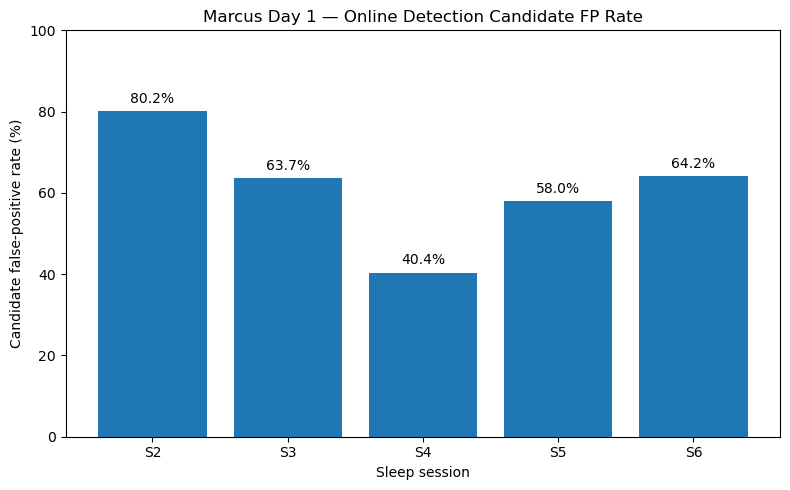

In [148]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    ["S2", "S3", "S4", "S5", "S6"],
    day1_fp_summary["fp_rate"]
)

for bar, fp in zip(
    bars,
    day1_fp_summary["fp_rate"]
):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        f"{fp:.1f}%",
        ha="center"
    )

plt.xlabel("Sleep session")
plt.ylabel("Candidate false-positive rate (%)")
plt.title("Marcus Day 1 — Online Detection Candidate FP Rate")

plt.ylim(0, 100)
plt.tight_layout()
plt.show()

What differs between matched online detections and candidate false positives, and why does S4 have fewer candidate FPs?

In [151]:
fp_trains_day1 = {}

for epoch_number, session in day1_sessions.items():

    # -------------------------
    # ONLINE
    # -------------------------

    epoch_start, epoch_stop, epoch_name = (
        nwbf.intervals["epochs"][epoch_number].to_numpy()[0]
    )

    mask = (
        (laser_timestamps > epoch_start) &
        (laser_timestamps <= epoch_stop)
    )

    laser_data_epoch = laser_data[mask].copy()
    laser_timestamps_epoch = laser_timestamps[mask]

    rising_edge_idx = np.where(
        np.diff(laser_data_epoch, prepend=0) == 1
    )[0]

    pulse_start_times = laser_timestamps_epoch[rising_edge_idx]

    n_complete_trains = len(pulse_start_times) // 20

    pulse_groups_session = pulse_start_times[
        :n_complete_trains * 20
    ].reshape(n_complete_trains, 20)

    # -------------------------
    # OFFLINE
    # -------------------------

    offline = (
        sgrip.RippleTimesV1()
        & {
            "nwb_file_name": nwb_file_name,
            "target_interval_list_name": session,
            "ripple_param_name": "default_trodes",
        }
    ).fetch1_dataframe()

    offline_start = offline["start_time"].to_numpy()
    offline_end = offline["end_time"].to_numpy()

    # -------------------------
    # FIND FP TRAINS
    # -------------------------

    online_has_match = []

    for train in pulse_groups_session:

        pulse_matches = (
            (train[:, None] >= offline_start[None, :]) &
            (train[:, None] <= offline_end[None, :])
        )

        online_has_match.append(
            np.any(pulse_matches)
        )

    online_has_match = np.array(online_has_match)

    # Save the COMPLETE 20-pulse FP trains
    fp_trains_day1[session] = (
        pulse_groups_session[~online_has_match]
    )

what is the FP's temporal distance to the nearest offline SWR interval.

In [152]:
fp_distance_results = []

for session in day1_sessions.values():

    # Get offline SWRs again
    offline = (
        sgrip.RippleTimesV1()
        & {
            "nwb_file_name": nwb_file_name,
            "target_interval_list_name": session,
            "ripple_param_name": "default_trodes",
        }
    ).fetch1_dataframe()

    offline_start = offline["start_time"].to_numpy()
    offline_end = offline["end_time"].to_numpy()

    fp_trains = fp_trains_day1[session]

    for train in fp_trains:

        train_start = train[0]
        train_end = train[-1]

        # Distance from this FP train to every offline SWR
        distances = np.where(
            train_end < offline_start,
            offline_start - train_end,
            np.where(
                train_start > offline_end,
                train_start - offline_end,
                0
            )
        )

        nearest_distance = np.min(distances)

        fp_distance_results.append({
            "session": session,
            "fp_time": train_start,
            "nearest_offline_distance_ms":
                nearest_distance * 1000
        })


fp_distances = pd.DataFrame(fp_distance_results)

fp_distances

,session,fp_time,nearest_offline_distance_ms
0,03_s2,1.785608e+09,1540.981770
1,03_s2,1.785608e+09,10.966778
2,03_s2,1.785608e+09,1301.412821
3,03_s2,1.785608e+09,343.136787
4,03_s2,1.785608e+09,83.234310
...,...,...,...
5476,11_s6,1.785627e+09,214.202642
5477,11_s6,1.785627e+09,375.338316
5478,11_s6,1.785627e+09,701.209068
5479,11_s6,1.785627e+09,160.202026


In [153]:
fp_distances[
    "nearest_offline_distance_ms"
].describe(
    percentiles=[
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ]
)

count     5481.000000
mean      2029.081891
std       2724.027658
min          0.033617
25%        362.771273
50%       1056.078911
75%       2482.031584
90%       5180.127144
95%       7484.569311
99%      13929.569101
max      19856.817484
Name: nearest_offline_distance_ms, dtype: float64

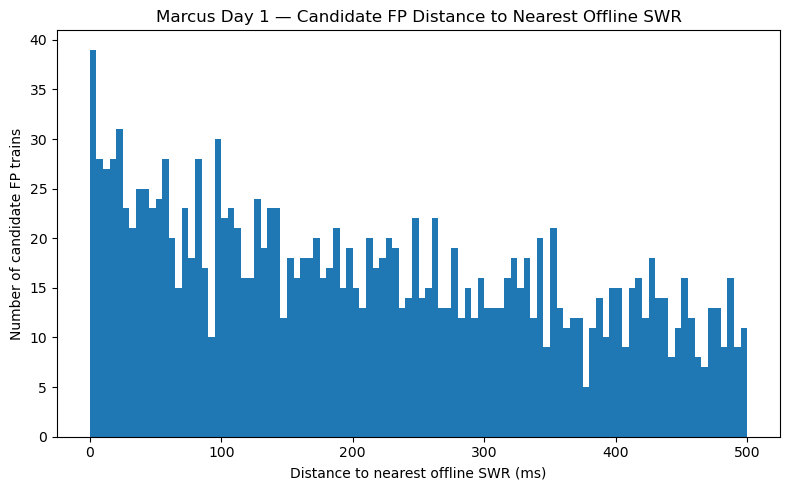

In [154]:
plt.figure(figsize=(8, 5))

plt.hist(
    fp_distances["nearest_offline_distance_ms"],
    bins=100,
    range=(0, 500)
)

plt.xlabel("Distance to nearest offline SWR (ms)")
plt.ylabel("Number of candidate FP trains")
plt.title("Marcus Day 1 — Candidate FP Distance to Nearest Offline SWR")

plt.tight_layout()
plt.show()

In [155]:
dist = fp_distances["nearest_offline_distance_ms"]

for threshold in [10, 20, 50, 100, 200, 500]:

    n = (dist <= threshold).sum()
    pct = 100 * n / len(dist)

    print(
        f"Within {threshold:3d} ms: "
        f"{n:4d} / {len(dist)} "
        f"({pct:.1f}%)"
    )

Within  10 ms:   67 / 5481 (1.2%)
Within  20 ms:  122 / 5481 (2.2%)
Within  50 ms:  270 / 5481 (4.9%)
Within 100 ms:  483 / 5481 (8.8%)
Within 200 ms:  860 / 5481 (15.7%)
Within 500 ms: 1699 / 5481 (31.0%)


Comparing amplitude and ripple power for matched and unmatched events

In [158]:
session = "07_s4"

clear_fp_times = (
    fp_distances[
        (fp_distances["session"] == session) &
        (fp_distances["nearest_offline_distance_ms"] > 500)
    ]
    ["fp_time"]
    .to_numpy()
)

print("Clear FPs (>500 ms away):", len(clear_fp_times))

Clear FPs (>500 ms away): 355


In [159]:
matched_times = matched_events_day1[session]

print("Matched online events:", len(matched_times))

Matched online events: 782


In [160]:
rng = np.random.default_rng(42)

n_examples = 10

matched_examples = rng.choice(
    matched_times,
    size=min(n_examples, len(matched_times)),
    replace=False
)

fp_examples = rng.choice(
    clear_fp_times,
    size=min(n_examples, len(clear_fp_times)),
    replace=False
)

print("Matched examples:")
print(np.sort(matched_examples))

print("\nClear FP examples:")
print(np.sort(fp_examples))

Matched examples:
[1.78562497e+09 1.78562500e+09 1.78562504e+09 1.78562514e+09
 1.78562535e+09 1.78562537e+09 1.78562595e+09 1.78562621e+09
 1.78562634e+09 1.78562662e+09]

Clear FP examples:
[1.78561709e+09 1.78561745e+09 1.78561748e+09 1.78561749e+09
 1.78561750e+09 1.78561754e+09 1.78561758e+09 1.78561772e+09
 1.78561773e+09 1.78561780e+09]
